# 04 — Breach Investigation: When the Model Fails

**Lesson:** A 5% breach rate doesn't mean breaches are evenly distributed. They cluster during crises, and the model is wrong exactly when you need it most.

This notebook answers: *where, when, and why does the VaR model actually fail?*

## ⚙️ Parameters

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
WINDOW = 252
CONFIDENCE = 0.95

# Regime boundaries (approximate)
PRE_COVID_END = "2020-02-19"
COVID_END = "2020-06-30"
POST_COVID_START = "2020-07-01"

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.historical_var import historical_var
from src.rolling import rolling_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Shared data — used by all sections
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)
result = rolling_var(returns, window=WINDOW, confidence=CONFIDENCE)

Prepared 2143 daily returns (2018-01-03 to 2026-07-15) from 2144 price observations.


---

## Part A: Breach clustering

If breaches were random, they'd be evenly scattered. Are they?

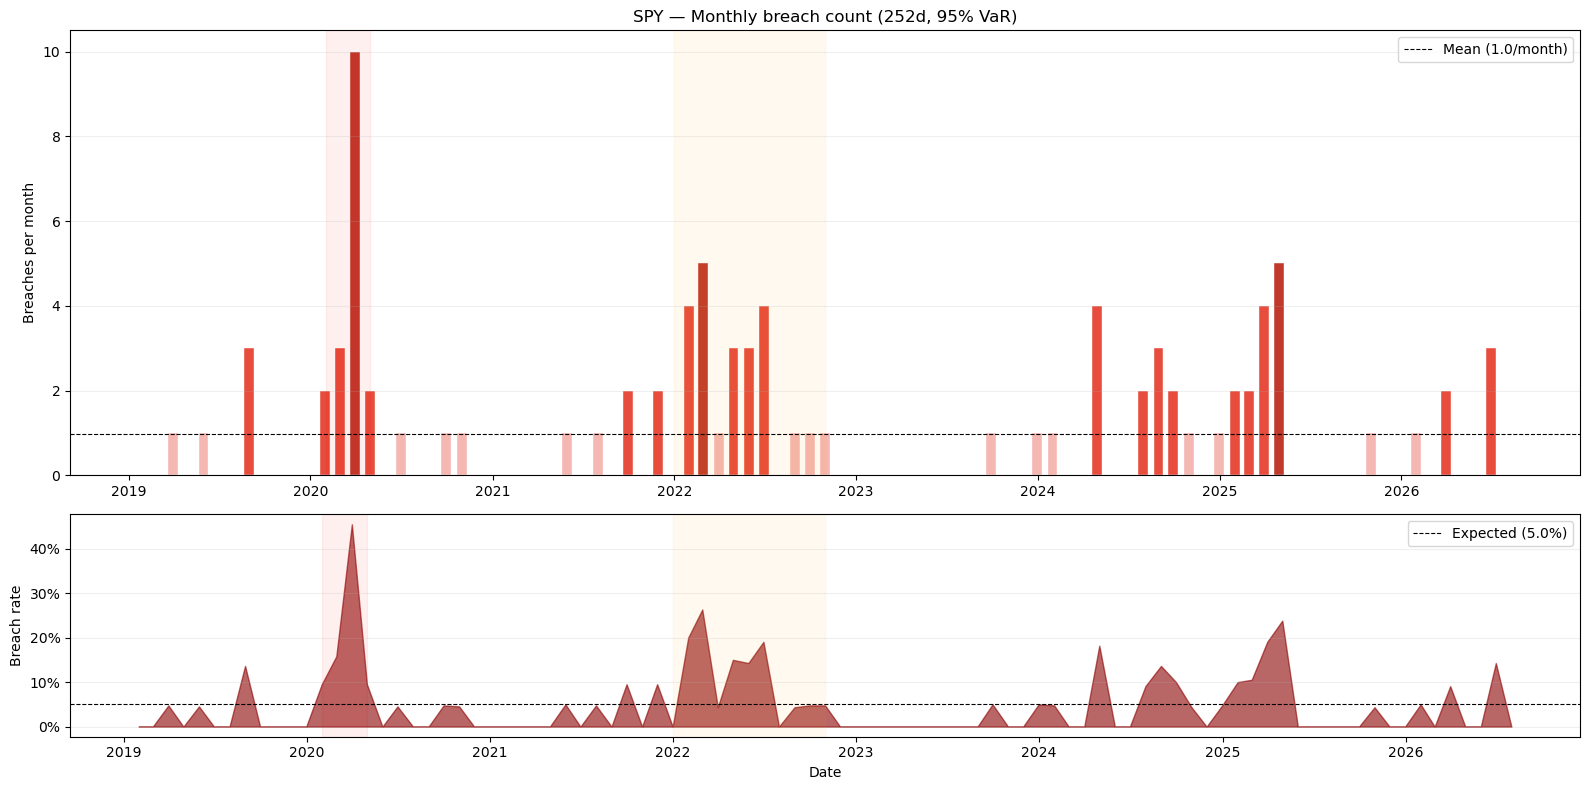

Worst 5 months for breaches:
  March 2020            10 breaches
  April 2025             5 breaches
  February 2022          5 breaches
  January 2022           4 breaches
  June 2022              4 breaches


In [4]:
# Aggregate breaches by month
breaches_by_month = result["Breach"].resample("ME").sum()
trading_days_by_month = result["Breach"].resample("ME").count()
breach_rate_by_month = breaches_by_month / trading_days_by_month

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [2, 1]})

# Top: bar chart of breach counts
colors_bars = ["#c0392b" if c >= 5 else "#e74c3c" if c >= 2 else "#f5b7b1" for c in breaches_by_month]
ax1.bar(breaches_by_month.index, breaches_by_month.values, width=20, color=colors_bars, edgecolor="white", linewidth=0.3)
ax1.axhline(breaches_by_month.mean(), color="black", linestyle="--", linewidth=0.8, label=f"Mean ({breaches_by_month.mean():.1f}/month)")

ax1.set_ylabel("Breaches per month")
ax1.set_title(f"{TICKER} — Monthly breach count ({WINDOW}d, {CONFIDENCE:.0%} VaR)")
ax1.legend()
ax1.grid(True, alpha=0.2, axis="y")

# Bottom: breach rate (% of trading days)
expected_rate = 1 - CONFIDENCE
ax2.fill_between(breach_rate_by_month.index, 0, breach_rate_by_month.values, alpha=0.6, color="darkred")
ax2.axhline(expected_rate, color="black", linestyle="--", linewidth=0.8, label=f"Expected ({expected_rate:.1%})")
ax2.set_ylabel("Breach rate")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend()
ax2.grid(True, alpha=0.2, axis="y")

# Annotate crisis periods on top chart
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"), alpha=0.06, color="red")
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

plt.tight_layout()
plt.show()

# Worst months
top_months = breaches_by_month.sort_values(ascending=False).head(5)
print("Worst 5 months for breaches:")
for date, count in top_months.items():
    print(f"  {date.strftime('%B %Y'):<20} {int(count):>3} breaches")

### What this shows

If breaches were independent and random, each month would have roughly the same number. Instead, they bunch up: March 2020 alone might account for more breaches than entire years of calm markets. The model is well-calibrated on average but catastrophically wrong during the periods when risk management matters most.

---

## Part B: The window cliff (synthetic)

What happens when a single large loss enters and exits the window? This is the mechanical heart of historical VaR.

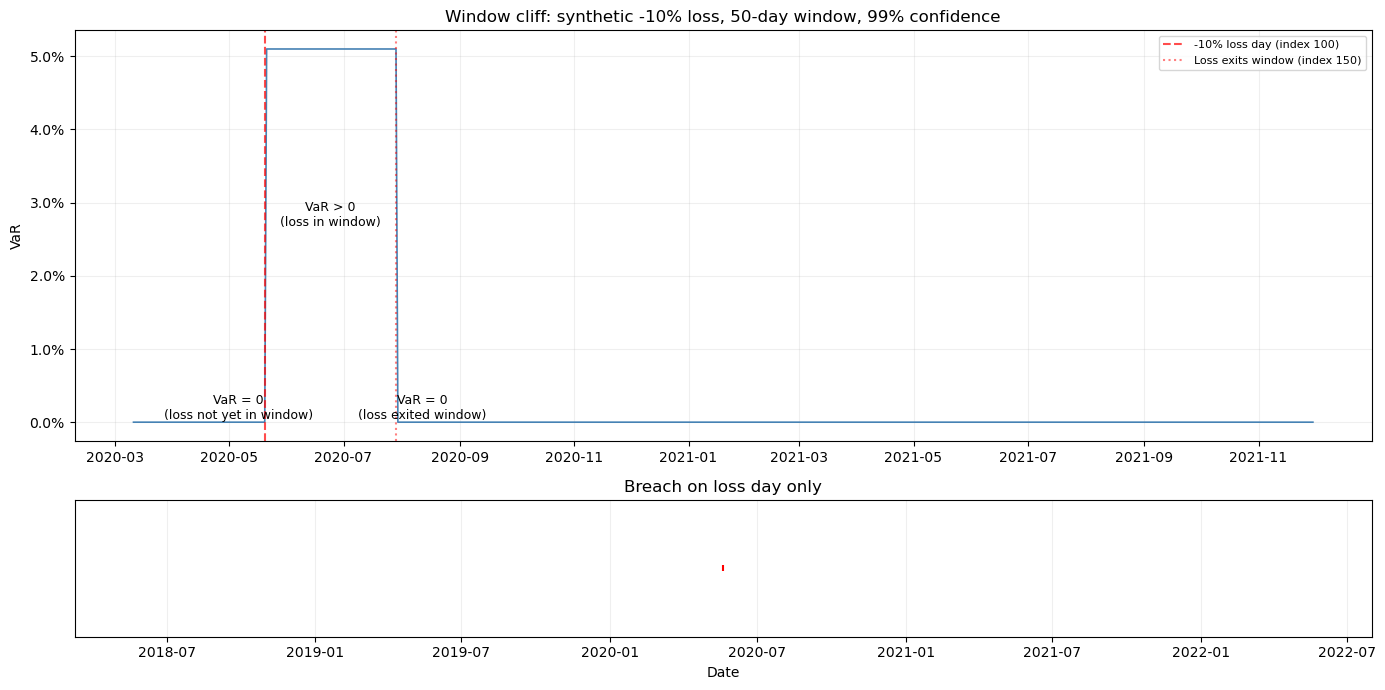

Day of -10% loss: VaR = -0.0000% → Breach: True
Day after loss enters: VaR = 5.1000%
Last day with loss in window: VaR = 5.1000%
Day loss exits window: VaR = 5.1000%


In [5]:
# Build synthetic series: 500 days of zeros, one -10% day at index 100
n_days = 500
loss_idx = 100
synthetic = np.zeros(n_days)
synthetic[loss_idx] = -0.10

dates_syn = pd.date_range("2020-01-01", periods=n_days, freq="B")
returns_syn = pd.Series(synthetic, index=dates_syn)

syn_window = 50
syn_result = rolling_var(returns_syn, window=syn_window, confidence=0.99)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]})

# Top: VaR over time
ax1.plot(syn_result.index, syn_result["VaR"], linewidth=1.2, color="steelblue")
ax1.axvline(dates_syn[loss_idx], color="red", linestyle="--", alpha=0.7, label=f"-10% loss day (index {loss_idx})")
ax1.axvline(dates_syn[loss_idx + syn_window], color="red", linestyle=":", alpha=0.5, label=f"Loss exits window (index {loss_idx + syn_window})")

# Annotate regions
mid = ax1.get_ylim()[1] * 0.5 if ax1.get_ylim()[1] > 0 else 0.02
ax1.annotate("VaR = 0\n(loss not yet in window)", xy=(dates_syn[loss_idx - 10], 0),
            fontsize=9, ha="center", va="bottom")
ax1.annotate("VaR > 0\n(loss in window)", xy=(dates_syn[loss_idx + syn_window // 2], mid),
            fontsize=9, ha="center")
ax1.annotate("VaR = 0\n(loss exited window)", xy=(dates_syn[loss_idx + syn_window + 10], 0),
            fontsize=9, ha="center", va="bottom")

ax1.set_ylabel("VaR")
ax1.set_title(f"Window cliff: synthetic -10% loss, {syn_window}-day window, 99% confidence")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.2)

# Bottom: breach flags
breach_idx = np.where(syn_result["Breach"])[0]
ax2.scatter(syn_result.index[breach_idx], np.ones(len(breach_idx)),
           color="red", s=15, marker="|")
ax2.set_ylim(0, 2)
ax2.set_yticks([])
ax2.set_xlabel("Date")
ax2.set_title("Breach on loss day only")
ax2.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.show()

print(f"Day of -10% loss: VaR = {syn_result.loc[dates_syn[loss_idx], 'VaR']:.4%} → Breach: {syn_result.loc[dates_syn[loss_idx], 'Breach']}")
print(f"Day after loss enters: VaR = {syn_result.loc[dates_syn[loss_idx + 1], 'VaR']:.4%}")
print(f"Last day with loss in window: VaR = {syn_result.loc[dates_syn[loss_idx + syn_window - 1], 'VaR']:.4%}")
print(f"Day loss exits window: VaR = {syn_result.loc[dates_syn[loss_idx + syn_window], 'VaR']:.4%}")

### Why this matters

The window cliff is mechanical, not statistical. A single extreme day creates a known, predictable bump in VaR that lasts exactly `window` days. In real markets, this means:

- **March 2020 crash days** entered the 252-day window one by one, each raising VaR slightly
- **They stayed for exactly 252 trading days** (~1 calendar year)
- **Around March 2021**, the last COVID crash day dropped out of the 252-day window, causing VaR to tick down

This is why the 252-day VaR was elevated through all of 2020 — not because 2020 remained risky, but because the window mechanically carried the crash.

---

## Part C: Breach rate by regime

The model looks well-calibrated overall. But how does it perform within each regime?

In [6]:
regimes = {
    "Pre-COVID (2018–Feb 2020)": (result.index < PRE_COVID_END),
    f"COVID crash (Feb–Jun 2020)": ((result.index >= PRE_COVID_END) & (result.index <= COVID_END)),
    "Post-COVID (Jul 2020–present)": (result.index >= POST_COVID_START),
}

print(f"{'Regime':<35} {'Days':>7} {'Breaches':>9} {'Rate':>8} {'Expected':>9}")
print("-" * 71)
for name, mask in regimes.items():
    subset = result[mask]
    n = len(subset)
    b = subset["Breach"].sum()
    rate = b / n if n > 0 else 0
    print(f"{name:<35} {n:>7} {int(b):>9} {rate:>7.2%} {1 - CONFIDENCE:>8.2%}")

Regime                                 Days  Breaches     Rate  Expected
-----------------------------------------------------------------------
Pre-COVID (2018–Feb 2020)               282         7   2.48%    5.00%
COVID crash (Feb–Jun 2020)               93        16  17.20%    5.00%
Post-COVID (Jul 2020–present)          1516        67   4.42%    5.00%


### The regime problem

If the breach rate varies dramatically by regime, the model is **conditionally miscalibrated**. It looks fine on average because high-breach periods are offset by low-breach periods. But in real time, you don't get to average across regimes — you live through them one at a time.

During the COVID crash, the model severely understated risk (breach rate >> 5%). In the calm pre-COVID years, it overstated risk (breach rate << 5%). Neither answer is useful to someone making decisions in real time.

---

## Part D: Confidence-level comparison

At 99% confidence, breaches should be even rarer (~1% of days). Are they?

In [7]:
result_99 = rolling_var(returns, window=WINDOW, confidence=0.99)

summary_95 = breach_summary(result, confidence=0.95)
summary_99 = breach_summary(result_99, confidence=0.99)

print(f"{'':<12} {'95% VaR':>12} {'99% VaR':>12}")
print("-" * 38)
print(f"{'Breaches':<12} {summary_95['breaches']:>12} {summary_99['breaches']:>12}")
print(f"{'Rate':<12} {summary_95['breach_rate']:>11.2%} {summary_99['breach_rate']:>11.2%}")
print(f"{'Expected':<12} {summary_95['expected_rate']:>11.2%} {summary_99['expected_rate']:>11.2%}")

                  95% VaR      99% VaR
--------------------------------------
Breaches               90           32
Rate               4.76%       1.69%
Expected           5.00%       1.00%


### 95% vs 99% breach concentration

The 99% breaches are even more concentrated than the 95% breaches. A single crisis can produce most of the 99% breaches for an entire decade. This is the fundamental tension in VaR: higher confidence means fewer breaches, but those few breaches are even more clustered and harder to anticipate.

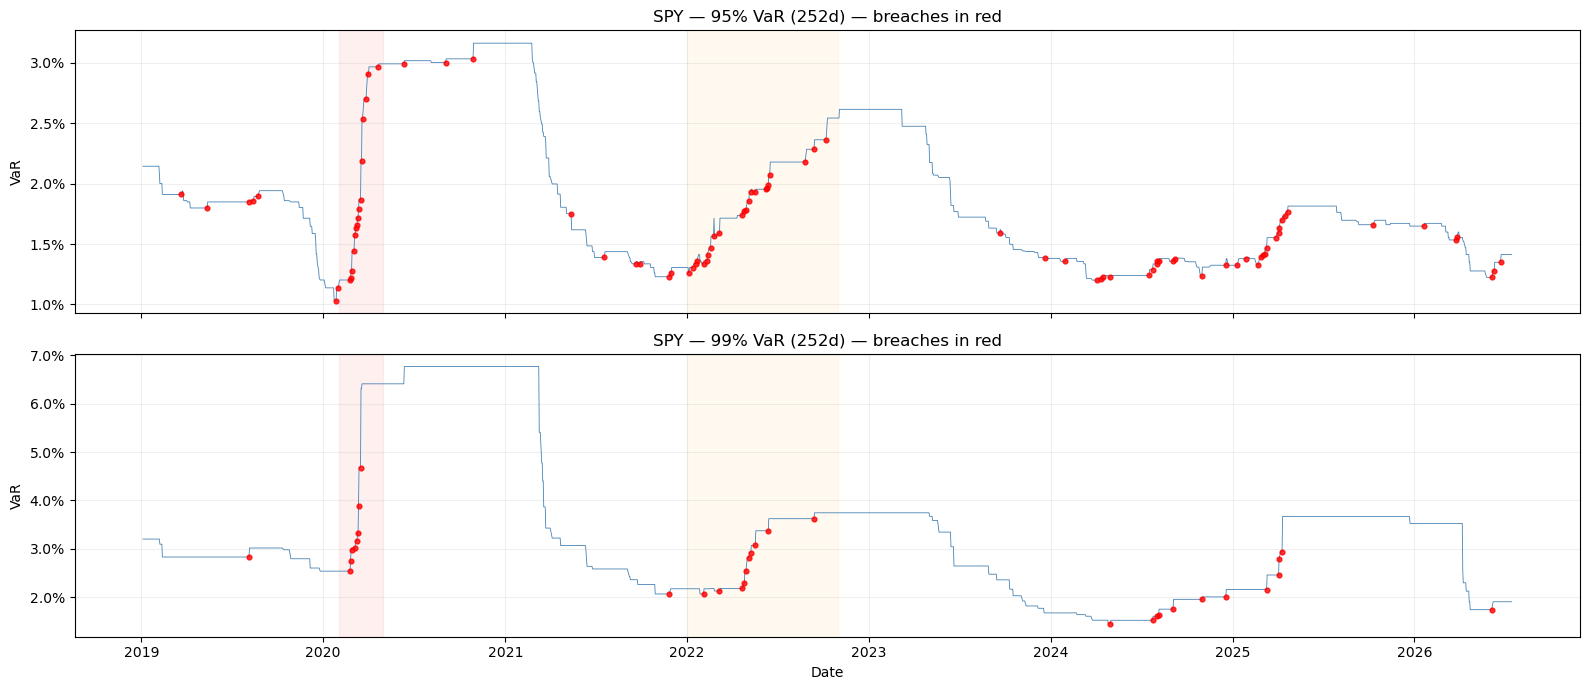

In [8]:
# Compare breach scatter
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax, res, conf, title in [
    (ax1, result, 0.95, "95% VaR"),
    (ax2, result_99, 0.99, "99% VaR"),
]:
    ax.plot(res.index, res["VaR"], linewidth=0.6, color="steelblue")
    ax.scatter(res.index[res["Breach"]], res["VaR"][res["Breach"]],
              color="red", s=12, alpha=0.8, zorder=5)
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"), alpha=0.06, color="red")
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")
    ax.set_ylabel("VaR")
    ax.set_title(f"{TICKER} — {title} ({WINDOW}d) — breaches in red")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
    ax.grid(True, alpha=0.2)

ax2.set_xlabel("Date")
plt.tight_layout()
plt.show()

---

## Key insight

Historical VaR has three structural failure modes, all visible in this notebook:

1. **Breach clustering:** The 5% breach rate is an average. In practice, breaches concentrate during crises. The model is well-calibrated over decades but wrong during the months when risk management actually matters.

2. **The window cliff:** Extreme returns enter and exit the window mechanically, creating predictable bumps in VaR. This is not a reflection of changing risk — it's a reflection of the window design.

3. **Regime dependence:** The model's calibration depends entirely on which regime you're in. Pre-COVID calm and post-COVID calm both look fine, but the model during COVID itself was consistently wrong.

**The meta-lesson:** A single VaR number, at a single window, at a single confidence level, is dangerous. A production risk system needs multiple windows, multiple methods, and continuous backtesting with breach-clustering diagnostics.

This concludes the four-notebook demonstration series. All code lives in `src/` — the notebooks are pure exploration.